In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, LabelEncoder,label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from itertools import cycle




In [21]:
# THIS IS THE ONLY CHANGE NEEDED FOR LOADING
train_df = pd.read_csv("NSLKDD_Train.csv", header=None)
test_df  = pd.read_csv("NSLKDD_Test.csv",  header=None)

print(f"Raw train shape: {train_df.shape}")
print(f"Raw test  shape: {test_df.shape}")

# NOW assign correct column names (41 features + labels)
columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
           'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
           'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
           'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
           'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
           'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
           'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
           'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
           'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'labels']

train_df.columns = columns
test_df.columns  = columns

print("Columns fixed. First few rows:")
print(train_df.head(2))

Raw train shape: (118813, 42)
Raw test  shape: (29705, 42)
Columns fixed. First few rows:
   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0  duration  protocol_type  service  flag  src_bytes  dst_bytes  land   
1         0              1       30     5          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0  wrong_fragment  urgent  hot  ...  dst_host_srv_count   
1               0       0    0  ...                  18   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0  dst_host_same_srv_rate  dst_host_diff_srv_rate   
1                    0.07                    0.07   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0  dst_host_same_src_port_rate  dst_host_srv_diff_host_rate   
1                          0.0                          0.0   

   dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
0  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate   
1           

In [22]:
def robust_label_mapper(val):
    if pd.isna(val):
        return None
    s = str(val).strip().lower().replace('.', '').replace('_', '')
    if s in ['0', 'normal']:        return 'normal'
    if s in ['1', 'dos']:           return 'dos'
    if s in ['2', 'probe']:         return 'probe'
    if s in ['3', 'r2l']:           return 'r2l'
    if s in ['4', 'u2r']:           return 'u2r'
    return None 

train_df['target'] = train_df['labels'].apply(robust_label_mapper)
test_df['target']  = test_df['labels'].apply(robust_label_mapper)

print("Before drop - Train:", len(train_df), "Test:", len(test_df))
train_df = train_df.dropna(subset=['target']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['target']).reset_index(drop=True)

print(f"\nFINAL CLEAN DATASET:")
print(f"Train samples : {len(train_df)}")
print(f"Test samples  : {len(test_df)}")
print("\nClass distribution:")
print(train_df['target'].value_counts().sort_index())

Before drop - Train: 118813 Test: 29705

FINAL CLEAN DATASET:
Train samples : 2718
Test samples  : 679

Class distribution:
target
dos       1052
normal     590
probe       40
r2l          9
u2r       1027
Name: count, dtype: int64


In [23]:

print("Starting preprocessing...")


cat_cols = ['protocol_type', 'service', 'flag']

train_cat = pd.get_dummies(train_df[cat_cols], prefix=cat_cols).astype(int)
test_cat  = pd.get_dummies(test_df[cat_cols],  prefix=cat_cols).astype(int)

train_cat = train_cat.loc[:, ~train_cat.columns.duplicated()]
test_cat  = test_cat.loc[:, ~test_cat.columns.duplicated()]

all_cat_cols = train_cat.columns.union(test_cat.columns)
train_cat = train_cat.reindex(columns=all_cat_cols, fill_value=0)
test_cat  = test_cat.reindex(columns=all_cat_cols, fill_value=0)

print(f"One-hot encoded features: {len(all_cat_cols)}")

Starting preprocessing...
One-hot encoded features: 14


In [24]:
numeric_part_train = train_df.drop(['labels', 'target'], axis=1, errors='ignore')
numeric_part_test  = test_df.drop(['labels', 'target'],  axis=1, errors='ignore')

numeric_part_train = numeric_part_train.astype('float64')
numeric_part_test  = numeric_part_test.astype('float64')

X_train = pd.concat([numeric_part_train.reset_index(drop=True), train_cat.reset_index(drop=True)], axis=1)
X_test  = pd.concat([numeric_part_test.reset_index(drop=True),  test_cat.reset_index(drop=True)],  axis=1)

In [25]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),     columns=X_test.columns)

le = LabelEncoder()
y_train = le.fit_transform(train_df['target'])
y_test  = le.transform(test_df['target'])

In [26]:
print("\n" + "═"*70)
print("PREPROCESSING SUCCESSFUL!")
print("═"*70)
print(f"   Train samples : {X_train.shape[0]:,}")
print(f"   Test samples  : {X_test.shape[0]:,}")
print(f"   Features      : {X_train.shape[1]}")
print(f"   Classes       : {le.classes_}")
print(f"   Class counts  : dos={sum(y_train==0)}, normal={sum(y_train==1)}, probe={sum(y_train==2)}, r2l={sum(y_train==3)}, u2r={sum(y_train==4)}")
print("═"*70)


══════════════════════════════════════════════════════════════════════
PREPROCESSING SUCCESSFUL!
══════════════════════════════════════════════════════════════════════
   Train samples : 2,718
   Test samples  : 679
   Features      : 55
   Classes       : ['dos' 'normal' 'probe' 'r2l' 'u2r']
   Class counts  : dos=1052, normal=590, probe=40, r2l=9, u2r=1027
══════════════════════════════════════════════════════════════════════


In [27]:

models = {
    "Decision Tree"      : DecisionTreeClassifier(max_depth=20),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, max_depth=25, n_jobs=-1, random_state=42),
    "Extra Trees"        : ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "Naive Bayes"        : GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "LightGBM"           : LGBMClassifier(n_estimators=400, num_leaves=64, verbose=-1)
}

print(f"Ready to train {len(models)} models")

Ready to train 6 models


In [28]:
results = []

print("Training models...\n")
for name, model in models.items():
    print(f"{name:20} → training...", end="")
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    # AUC (only if predict_proba exists)
    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    else:
        auc = None
    
    results.append({
        'Model'      : name,
        'Train Acc'  : accuracy_score(y_train, train_pred),
        'Test Acc'   : accuracy_score(y_test,  test_pred),
        'Precision'  : precision_score(y_test, test_pred, average='weighted'),
        'Recall'     : recall_score(y_test,    test_pred, average='weighted'),
        'F1-Score'   : f1_score(y_test,       test_pred, average='weighted'),
        'AUC'        : auc if auc else "N/A"
    })
    
    print(f" Done → Test Acc: {results[-1]['Test Acc']:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df[['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1-Score']] = results_df[['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1-Score']].round(4)
results_df

Training models...

Decision Tree        → training... Done → Test Acc: 0.9956
Random Forest        → training... Done → Test Acc: 0.9971
Extra Trees          → training... Done → Test Acc: 0.9971
Naive Bayes          → training... Done → Test Acc: 0.9116
Logistic Regression  → training... Done → Test Acc: 0.9956
LightGBM             → training... Done → Test Acc: 0.9985


,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,AUC
0,Decision Tree,1.0000,0.9956,0.9956,0.9956,0.9953,0.996673
1,Random Forest,1.0000,0.9971,0.9971,0.9971,0.9970,0.999998
2,Extra Trees,1.0000,0.9971,0.9971,0.9971,0.9968,0.999998
3,Naive Bayes,0.9702,0.9116,0.9922,0.9116,0.9455,0.997079
4,Logistic Regression,0.9993,0.9956,0.9956,0.9956,0.9953,0.999996
5,LightGBM,1.0000,0.9985,0.9985,0.9985,0.9985,1.000000



Best Model: LightGBM → 0.9985 Test Accuracy


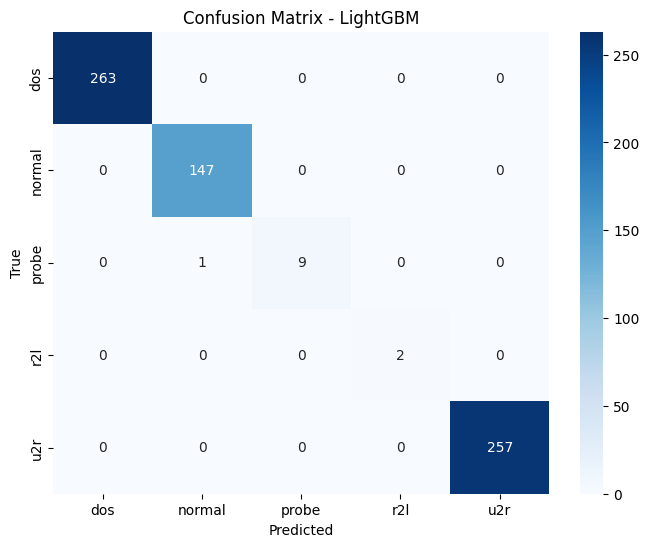


Classification Report:
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00       263
      normal       0.99      1.00      1.00       147
       probe       1.00      0.90      0.95        10
         r2l       1.00      1.00      1.00         2
         u2r       1.00      1.00      1.00       257

    accuracy                           1.00       679
   macro avg       1.00      0.98      0.99       679
weighted avg       1.00      1.00      1.00       679



In [29]:
# Best model by Test Accuracy
best_row = results_df.loc[results_df['Test Acc'].idxmax()]
best_name = best_row['Model']
best_model = models[best_name]

print(f"\nBest Model: {best_name} → {best_row['Test Acc']:.4f} Test Accuracy")

# Predictions
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

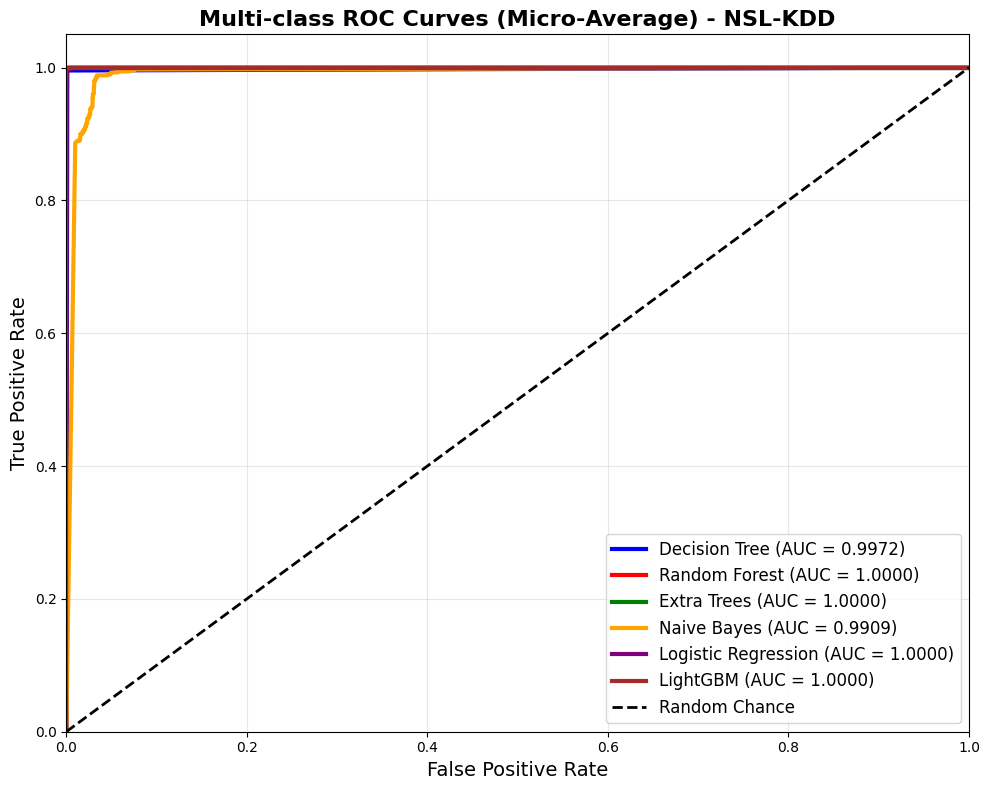

Final AUC Scores (Micro-averaged):
Decision Tree        → Micro-AUC: 0.99724
Random Forest        → Micro-AUC: 0.99999
Extra Trees          → Micro-AUC: 1.00000
Naive Bayes          → Micro-AUC: 0.99091
Logistic Regression  → Micro-AUC: 0.99998
LightGBM             → Micro-AUC: 1.00000


In [ ]:
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
n_classes = y_test_bin.shape[1]


plt.figure(figsize=(10, 8))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for (name, model), color in zip(models.items(), colors):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:  
        y_score = model.decision_function(X_test)
        from scipy.special import expit
        y_score = expit(y_score)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"],
             label=f'{name} (AUC = {roc_auc["micro"]:.4f})',
             color=color, linewidth=3)


plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-class ROC Curves (Micro-Average) - NSL-KDD', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final AUC Scores (Micro-averaged):")
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = expit(model.decision_function(X_test))
    micro_auc = roc_auc_score(y_test_bin, y_prob, average='micro')
    print(f"{name:20} → Micro-AUC: {micro_auc:.5f}")